# Evaluación 1

**Integrante 1:** Cristina Morán

**Integrante 2:** Alonso Valderrama

**Integrante 3:** Amasis Guzmán

**Correo Electrónico integrante 1:** cristina.moran2201@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** alonso.valderrama2201@alumnos.ubiobio.cl

**Correo Electrónico integrante 3:** amasis.guzman2201@alumnos.ubiobio.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 1 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

#Carga de datos

In [1]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv

--2026-04-15 02:06:08--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2771759 (2.6M) [text/plain]
Saving to: ‘dataset_churn_dirty.csv.7’

dataset_churn_dirty 100%[===================>]   2.64M  --.-KB/s    in 0.1s    

^C


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder

In [3]:
#Carga el set de datos
data = pd.read_csv('dataset_churn_dirty.csv')

#Para mostrar en una tabla los datos del archivo
data.head() 

,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
0,1,39.0,NaN,76,42,30.297419,0,70965.479058,47431.757551,Other,Enterprise,West,NaN,Yes,Desktop,1
1,2,69.0,1.352838e+06,46,27,50.666766,3,62653.316701,26134.009301,Other,Basic,South,Debit Card,No,Mobile,1
2,3,NaN,9.127957e+05,83,23,53.086839,1,46918.415548,15390.195033,NaN,Enterprise,West,NaN,No,Mobile,0
3,4,79.0,7.955275e+05,45,23,55.197774,1,22665.546094,41163.281718,Female,Premium,South,Debit Card,No,Tablet,1
4,5,52.0,4.425135e+05,98,29,67.781999,3,58510.036769,14704.401069,Male,Basic,West,Credit Card,Yes,Mobile,0


In [4]:
# Cantidad de observaciones y columnas
data.shape

(21000, 16)

Comentario: Esto quiere decir que los datos del archivo \.csv ingresado poseen 16 columnas y cada una de ellas 21000 valores\.

# Revisión de nulos

In [5]:
# revisión de valores faltantes y tipos de datos
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            21000 non-null  int64  
 1   age                    19964 non-null  float64
 2   monthly_income         19962 non-null  float64
 3   tenure_months          21000 non-null  int64  
 4   num_logins_last_month  21000 non-null  int64  
 5   avg_session_time       21000 non-null  float64
 6   support_tickets        21000 non-null  int64  
 7   account_balance        21000 non-null  float64
 8   last_payment_amount    21000 non-null  float64
 9   gender                 19947 non-null  object 
 10  subscription_type      21000 non-null  object 
 11  region                 21000 non-null  object 
 12  payment_method         19953 non-null  object 
 13  is_active              21000 non-null  object 
 14  preferred_device       21000 non-null  object 
 15  ch

Comentario respecto a nulos: Se puede apreciar que las 4 columnas con nulos son "age", "monthly\_income", "gender" y "payment\_method", además que la cantidad de datos total de cada columna debiera ser de 21000 entradas\.

De estos datos podemos observar la siguente cantidad de datos nulos:

age : 1036 datos nulos\.

monthly\_income: 1038 datos nulos\.

gender: 1053 datos nulos\.

payment\_method : 1047 datos nulos\.

Estos datos se mostraran en la siguente tabla con su % de nulos :

In [6]:
columnas_con_nulos = data.isna().sum()[data.isna().sum() > 0]
porcentaje_nulos = (columnas_con_nulos / data.shape[0]) * 100

resultado = pd.DataFrame({
    "Cantidad Nulos": columnas_con_nulos,
    "Porcentaje Nulos (%)": porcentaje_nulos
}).round(2)

resultado

,Cantidad Nulos,Porcentaje Nulos (%)
age,1036,4.93
monthly_income,1038,4.94
gender,1053,5.01
payment_method,1047,4.99


Observamos que entre estas 4 columnas tan solo el 5% o menos son nulos\.

# Revisión de atípicos

In [39]:
# Funciones para revisión de atípicos
def buscar_atipicos(data : pd.DataFrame, columna : str) -> pd.DataFrame:
  """
  Busca valores atípicos en una columna.
  """
  # Calcular los límites
  Q1 = data[columna].quantile(0.25)
  Q3 = data[columna].quantile(0.75)
  # Calcula rango intercuartilico
  IQR = Q3 - Q1
  limite_inferior = Q1 - 1.5 * IQR 
  limite_superior = Q3 + 1.5 * IQR

  # Filtrar outliers
  return data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]

def obtener_cantidad_atipicos(data : pd.DataFrame, columnas : np.array) -> dict:
  """
  Obtiene la cantidad de atípicos por cada columna.
  """
  total_atipicos = {}
  for columna in data[columnas]:
    atipicos = buscar_atipicos(data, columna)
    total_atipicos[columna] = atipicos.shape[0]
  return total_atipicos


In [8]:
atipicos_por_columna = obtener_cantidad_atipicos(data, data.describe().columns)
atipicos_por_columna

{'customer_id': 0,
 'age': 213,
 'monthly_income': 534,
 'tenure_months': 0,
 'num_logins_last_month': 58,
 'avg_session_time': 332,
 'support_tickets': 89,
 'account_balance': 136,
 'last_payment_amount': 134,
 'churn': 0}

Analizando los datos podemos identificar la presencia de valores atípicos en múltiples variables, siendo las más relevantes: age, monthly\_income, num\_logins\_last\_month, avg\_session\_time, support\_tickets, account\_balance y last\_payment\_amount\.
 

# Existencia de valores atípicos \(outliers\)

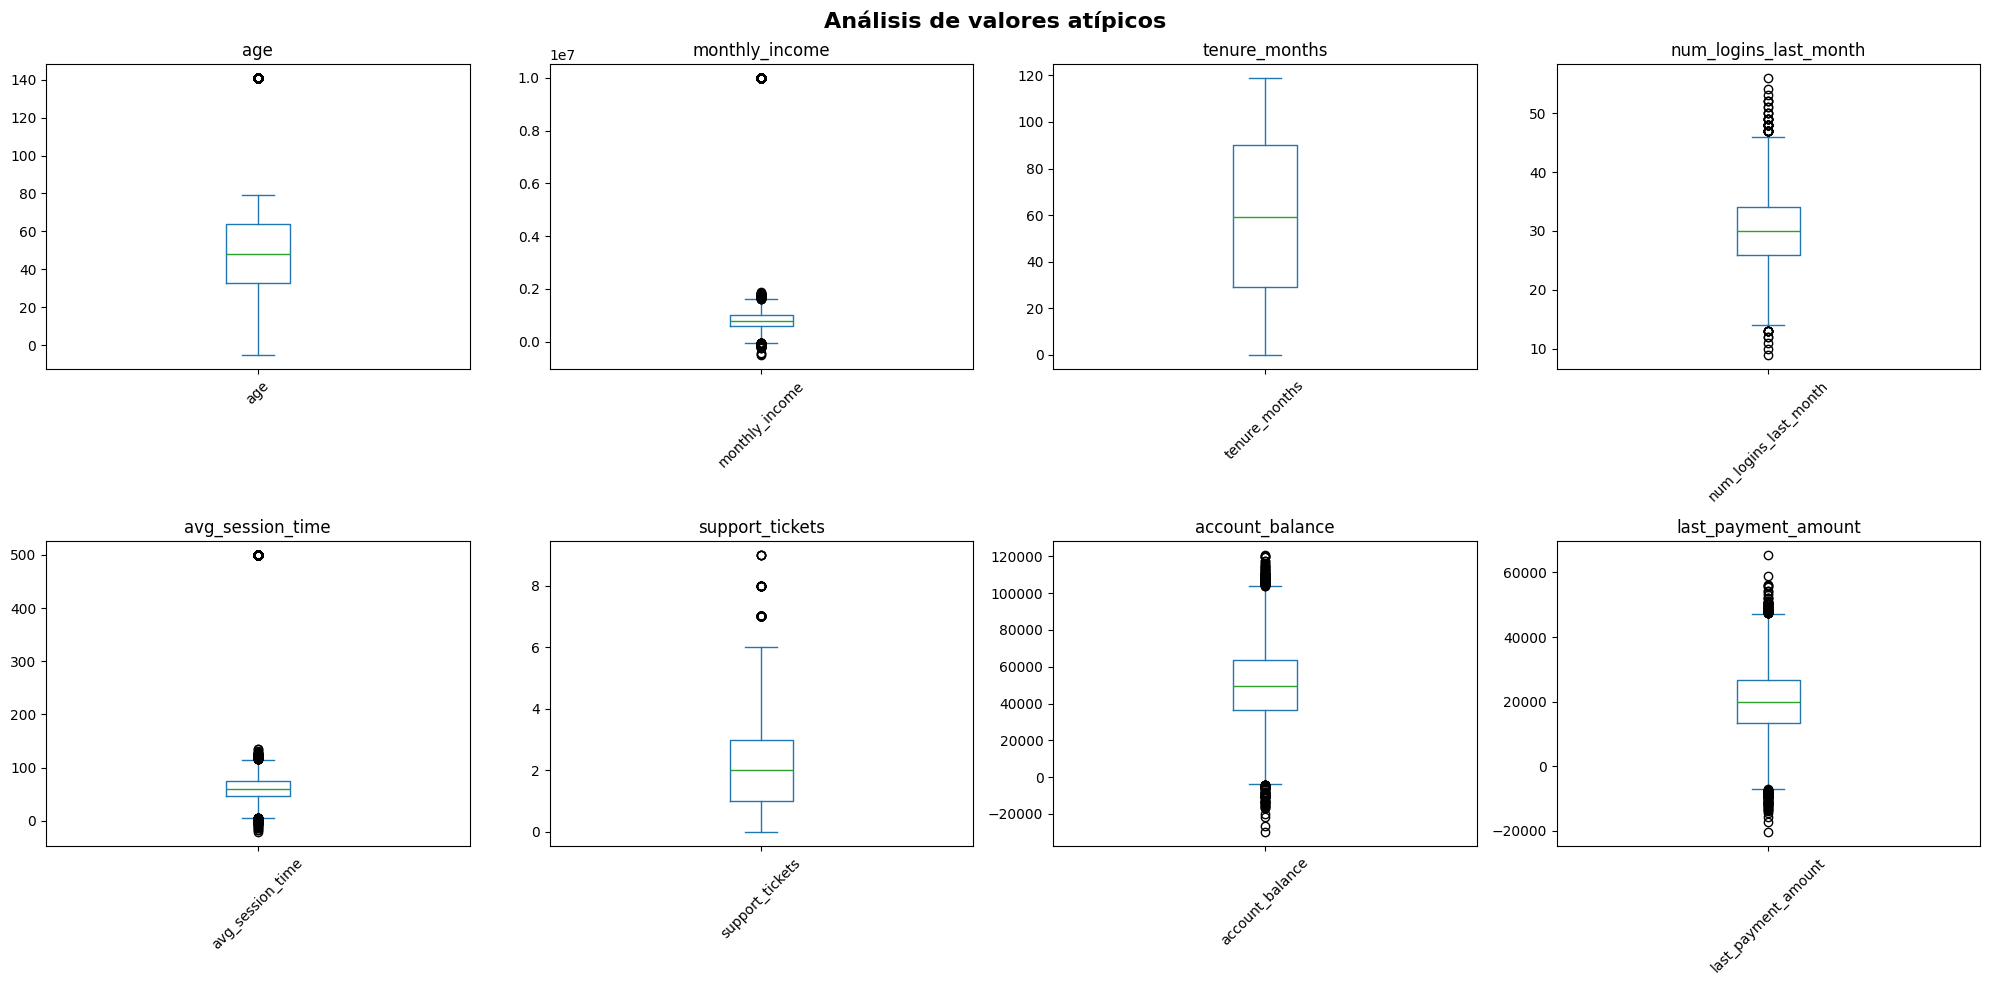

In [12]:
# Columnas numéricas para revisar atípicos
revision_atipicos = [
    'age',
    'monthly_income',
    'tenure_months',
    'num_logins_last_month',
    'avg_session_time',
    'support_tickets',
    'account_balance',
    'last_payment_amount'
]

# Crear subplots (2 filas x 4 columnas porque son 8 variables)
fig, axes = plt.subplots(2, 4, figsize=(20,10))
axes = axes.flatten()

# Graficar boxplots
for i, col in enumerate(revision_atipicos):
    data[col].plot(kind='box', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", labelrotation=45)

# Título general
plt.suptitle("Análisis de valores atípicos", fontsize=16, fontweight="bold")

# Ajuste de diseño
plt.tight_layout()

plt.show()

# Revisión de inconsistencias

In [19]:
# Detectar inconsistencias
inconsistentes = data[
    (data["age"] <= 0) |
    (data["monthly_income"] < 0) |
    (data["tenure_months"] < 0) |
    (data["num_logins_last_month"] < 0) |
    (data["avg_session_time"] < 0) |
    (data["support_tickets"] < 0) |
    (data["account_balance"] < 0) |
    (data["last_payment_amount"] < 0)
]

print("Registros inconsistentes encontrados:")
inconsistentes

Registros inconsistentes encontrados:


,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
47,48,38.0,9.393170e+05,119,28,51.699977,3,71143.120322,-8638.523066,NaN,Premium,North,Debit Card,Yes,Desktop,1
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
59,60,38.0,6.602348e+05,9,34,47.909770,2,71055.533036,-707.350603,Male,Enterprise,East,Debit Card,No,Tablet,0
62,63,77.0,NaN,37,25,77.341020,4,-3484.853555,19584.816007,Female,Enterprise,West,PayPal,No,Tablet,1
65,66,38.0,-1.000000e+05,81,33,55.581316,1,15548.135456,17107.203175,Other,Enterprise,North,Transfer,No,Mobile,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20909,2256,-5.0,4.745605e+05,22,28,57.801877,1,55557.157569,31697.060773,Other,Enterprise,North,Debit Card,No,Mobile,0
20922,7271,31.0,7.601867e+05,17,44,67.498106,1,56370.726597,-1097.518661,Female,Premium,East,Transfer,Yes,Mobile,1
20926,7888,63.0,4.528124e+05,26,45,107.170665,3,41752.594619,-1682.760110,Other,Premium,West,PayPal,Yes,Desktop,1
20927,15710,74.0,-1.000000e+05,78,39,29.099820,0,61893.441053,33285.361859,Other,Enterprise,North,PayPal,No,Mobile,0


Comentario: Tabla de inconsistencias totales

# Revisión de inconsistencias para cualitativas

Genero

In [23]:
data.gender.unique()

array(['Other', nan, 'Female', 'Male'], dtype=object)

Tipo de Subscripcion

In [25]:
data.subscription_type.unique()

array(['Enterprise', 'Basic', 'Premium'], dtype=object)

Region

In [27]:
data.region.unique()

array(['West', 'South', 'North', 'East'], dtype=object)

Metodo de Pago

In [29]:
data.payment_method.unique()

array([nan, 'Debit Card', 'Credit Card', 'PayPal', 'Transfer'],
      dtype=object)

Es activo

In [31]:
data.is_active.unique()

array(['Yes', 'No'], dtype=object)

Dispositivo favorito

In [33]:
data.preferred_device.unique()

array(['Desktop', 'Mobile', 'Tablet'], dtype=object)

# Revisión de duplicados

In [35]:
# Revisa la existencia de duplicados
data.duplicated().sum()

1000

In [37]:
# Obtiene los registos duplicados
data[data.duplicated(keep=False)].sort_values(by='customer_id')

,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
29,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20808,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
20676,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
81,82,74.0,3.940678e+05,12,38,81.451588,2,73386.737914,15850.188316,Female,Enterprise,East,Transfer,No,Mobile,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20660,19974,33.0,1.128085e+06,111,25,87.790691,1,84751.539493,16273.962321,Male,Premium,North,Transfer,Yes,Mobile,0
19976,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
20686,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
20258,19990,53.0,7.261838e+05,93,29,91.552765,5,70170.793757,21619.638950,Other,Basic,West,PayPal,No,Mobile,0


# Limpieza y transformación

In [ ]:
# Escriba su código acá

# Guarda set de datos limpio y transformado

In [15]:
# Escriba su código acá

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=412dc4ce-25a6-448b-a3d9-1501e633b989' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>